# Bài toán phân cụm phân cấp theo chiến lược hợp nhất (agglomerative)

1. cài cắm thư viện

In [3]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
from sklearn.decomposition import PCA 
from sklearn.cluster import AgglomerativeClustering 
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score 
import scipy.cluster.hierarchy as shc 

2. tiền xử lí dữ liệu

In [4]:
data = pd.read_csv(r'Z:\DOCUMENTS\KPDL\DataMining-Homework\Lab6-Phan-cum\Iris.csv')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [5]:
# Kiểm tra missing value
data.isnull().sum()

Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

In [6]:
# Xóa cột Id và Species
data = data.drop(['Id', 'Species'], axis = 1)
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   SepalLengthCm  150 non-null    float64
 1   SepalWidthCm   150 non-null    float64
 2   PetalLengthCm  150 non-null    float64
 3   PetalWidthCm   150 non-null    float64
dtypes: float64(4)
memory usage: 4.8 KB


In [7]:
# Chuẩn hóa dữ liệu (Normalization)
scaler = StandardScaler() 
X_scaled = scaler.fit_transform(data) 
X_scaled = pd.DataFrame(X_scaled) 
X_scaled

,0,1,2,3
0,-0.900681,1.032057,-1.341272,-1.312977
1,-1.143017,-0.124958,-1.341272,-1.312977
2,-1.385353,0.337848,-1.398138,-1.312977
3,-1.506521,0.106445,-1.284407,-1.312977
4,-1.021849,1.263460,-1.341272,-1.312977
...,...,...,...,...
145,1.038005,-0.124958,0.819624,1.447956
146,0.553333,-1.281972,0.705893,0.922064
147,0.795669,-0.124958,0.819624,1.053537
148,0.432165,0.800654,0.933356,1.447956


In [8]:
# Giảm chiều dữ liệu bằng PCA (Principal component analysis) với n_components = 2
pca = PCA(n_components = 2) 
X_principal = pca.fit_transform(X_scaled) 
X_principal = pd.DataFrame(X_principal) 
X_principal.columns = ['P1', 'P2']

Text(0.5, 1.0, 'Phân bố các điểm dữ liệu')

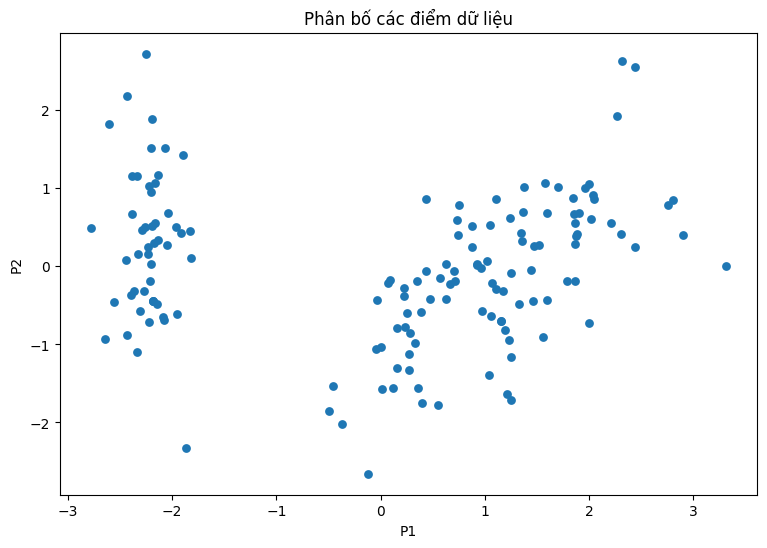

In [9]:
# Trực quan hóa các điểm dữ liệu trên đồ thị scatter plot
plt.figure(figsize=(9, 6))
plt.scatter(X_principal['P1'], X_principal['P2'], lw=0, s=40)
plt.xlabel('P1')
plt.ylabel('P2')
plt.title('Phân bố các điểm dữ liệu')

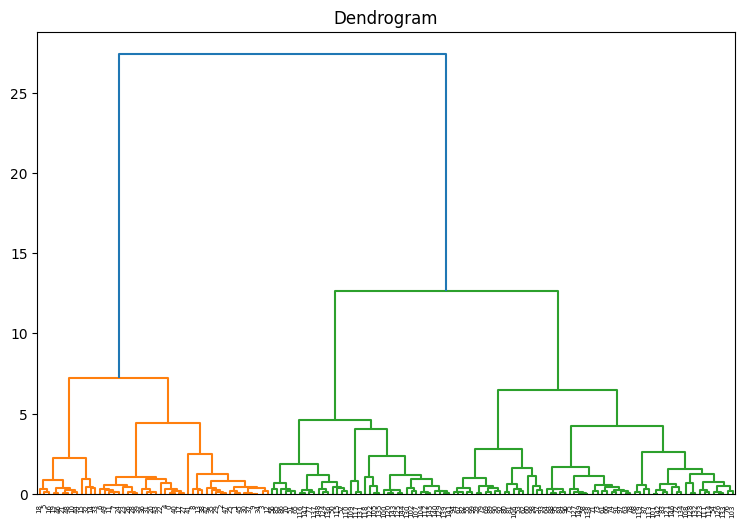

In [10]:
plt.figure(figsize =(9, 6)) 
plt.title('Dendrogram') 
Dendrogram = shc.dendrogram((shc.linkage(X_principal, method ='ward'))) 

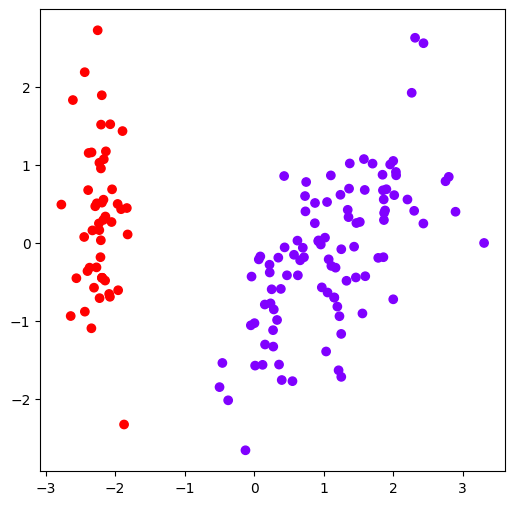

In [12]:
ac2 = AgglomerativeClustering(n_clusters = 2) 
labels_ac2 = ac2.fit_predict(X_principal)
# Trực quan hóa kết quả phân cụm
plt.figure(figsize =(6, 6)) 
plt.scatter(X_principal['P1'], X_principal['P2'],  c = labels_ac2, cmap ='rainbow') 
plt.show() 

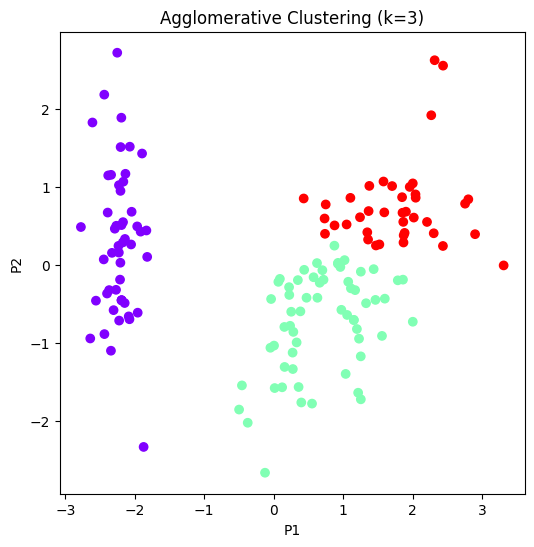

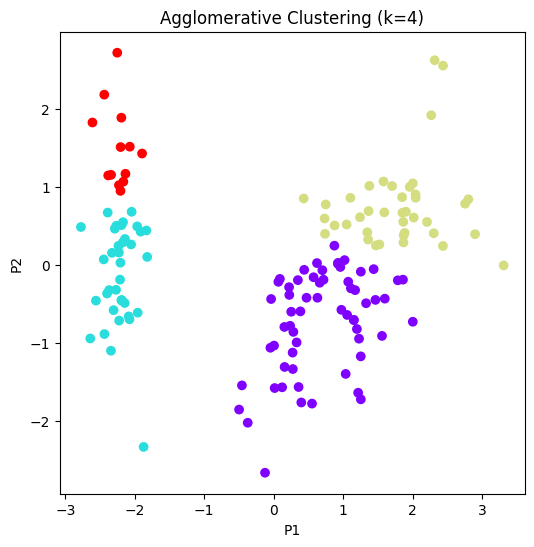

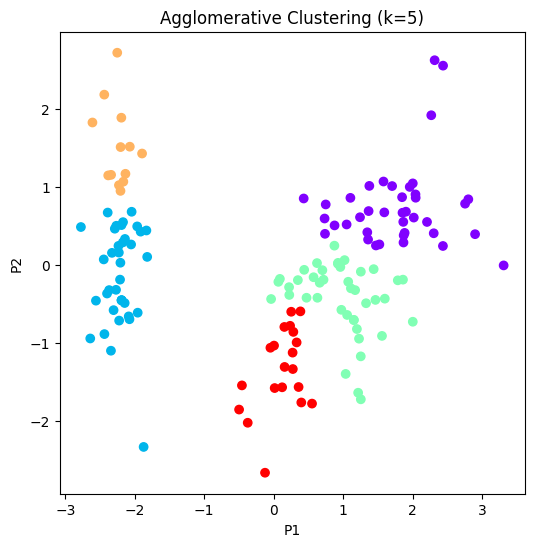

In [13]:
for k in range(3,6):
    models = AgglomerativeClustering(n_clusters=k)
    labels = models.fit_predict(X_principal)

    plt.figure(figsize=(6, 6))
    plt.scatter(X_principal['P1'], X_principal['P2'], c=labels, cmap='rainbow')
    plt.title(f'Agglomerative Clustering (k={k})')
    plt.xlabel('P1')
    plt.ylabel('P2')
    plt.show()

silhouette Score for k=2: 0.6130
silhouette Score for k=3: 0.5103
silhouette Score for k=4: 0.4603
silhouette Score for k=5: 0.4116


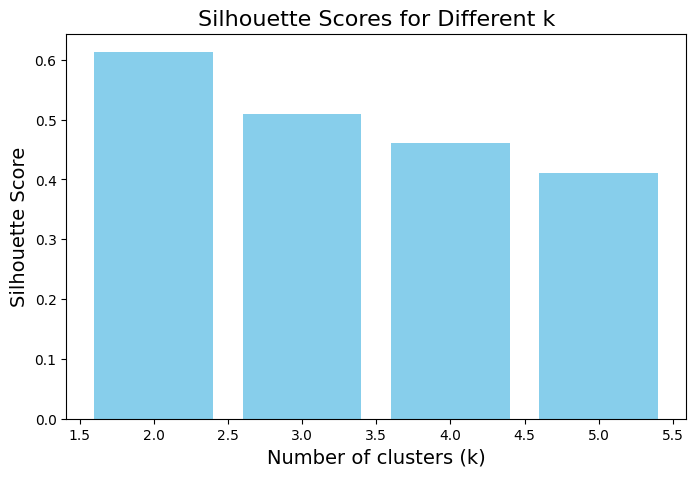

In [17]:
silhouetteScore = []
for k in range(2,6):
    models = AgglomerativeClustering(n_clusters=k)
    labels = models.fit_predict(X_principal)
    score = silhouette_score(X_principal,labels)
    silhouetteScore.append(score)
    print(f"silhouette Score for k={k}: {score:.4f}")

plt.figure(figsize=(8, 5))
plt.bar(range(2,6), silhouetteScore, color='skyblue')
plt.xlabel('Number of clusters (k)', fontsize=14)
plt.ylabel('Silhouette Score', fontsize=14)
plt.title('Silhouette Scores for Different k', fontsize=16)
plt.show()

## phần 2


3. Bài tập: Thực hành phân cụm phân cấp trên dữ liệu shopping data (shopping_data.csv)
- Yêu cầu:
    + 3.1. Hiểu và tiền xử lý dữ liệu
    + 3.2. Chỉ sử dụng 2 thuộc tính 'Annual Income k$' và 'Spending Score' để trực quan hóa phân bố các điểm dữ liệu trên biểu đồ phân tán (scatter plot)
    + 3.3. Trực quan hóa quá trình phân cấp cụm dữ liệu bằng dendrogram.
    + 3.4. Xây dựng mô hình phân cụm phân cấp AgglomerativeClustering với n_clusters = 4. Vẽ biểu đồ trực quan hóa kết quả phân cụm.
    + 3.5. Đánh giá chất lượng phân cụm bằng chỉ số silhouette_score.

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import scipy.cluster.hierarchy as shc
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
import os

In [19]:
path = r"Z:\DOCUMENTS\KPDL\DataMining-Homework\Lab6-Phan-cum\shopping_data.csv"

In [20]:
df = pd.read_csv(path)
print("---Thông tin bộ dự liệu---")
print(df.info())
print("\n---5 dong đầu tiên ---")
print(df.head())

---Thông tin bộ dự liệu---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None

---5 dong đầu tiên ---
   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


In [21]:
# Cột 3: Annual Income (k$), Cột 4: Spending Score (1-100)
data = df.iloc[:, [3, 4]].values
data

array([[ 15,  39],
       [ 15,  81],
       [ 16,   6],
       [ 16,  77],
       [ 17,  40],
       [ 17,  76],
       [ 18,   6],
       [ 18,  94],
       [ 19,   3],
       [ 19,  72],
       [ 19,  14],
       [ 19,  99],
       [ 20,  15],
       [ 20,  77],
       [ 20,  13],
       [ 20,  79],
       [ 21,  35],
       [ 21,  66],
       [ 23,  29],
       [ 23,  98],
       [ 24,  35],
       [ 24,  73],
       [ 25,   5],
       [ 25,  73],
       [ 28,  14],
       [ 28,  82],
       [ 28,  32],
       [ 28,  61],
       [ 29,  31],
       [ 29,  87],
       [ 30,   4],
       [ 30,  73],
       [ 33,   4],
       [ 33,  92],
       [ 33,  14],
       [ 33,  81],
       [ 34,  17],
       [ 34,  73],
       [ 37,  26],
       [ 37,  75],
       [ 38,  35],
       [ 38,  92],
       [ 39,  36],
       [ 39,  61],
       [ 39,  28],
       [ 39,  65],
       [ 40,  55],
       [ 40,  47],
       [ 40,  42],
       [ 40,  42],
       [ 42,  52],
       [ 42,  60],
       [ 43,

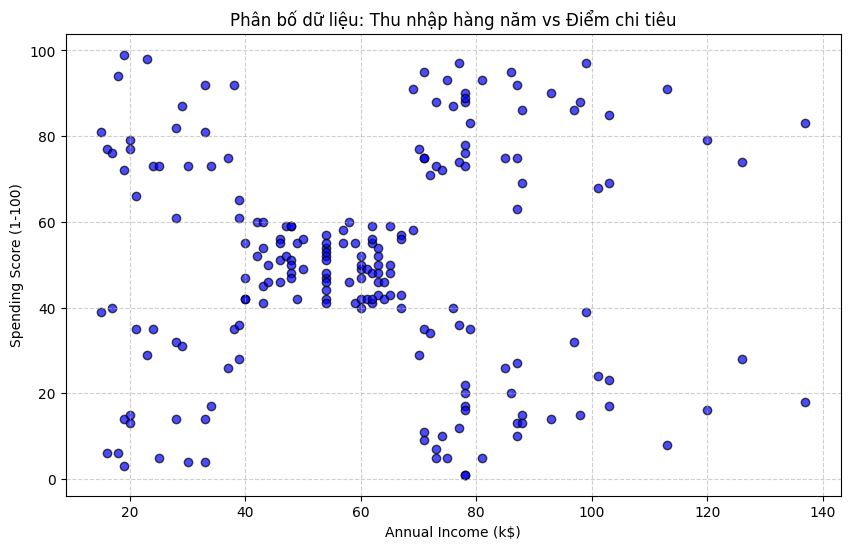

In [22]:
plt.figure(figsize=(10, 6))
plt.scatter(data[:, 0], data[:, 1], color='blue', edgecolors='k', alpha=0.7)
plt.title("Phân bố dữ liệu: Thu nhập hàng năm vs Điểm chi tiêu")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

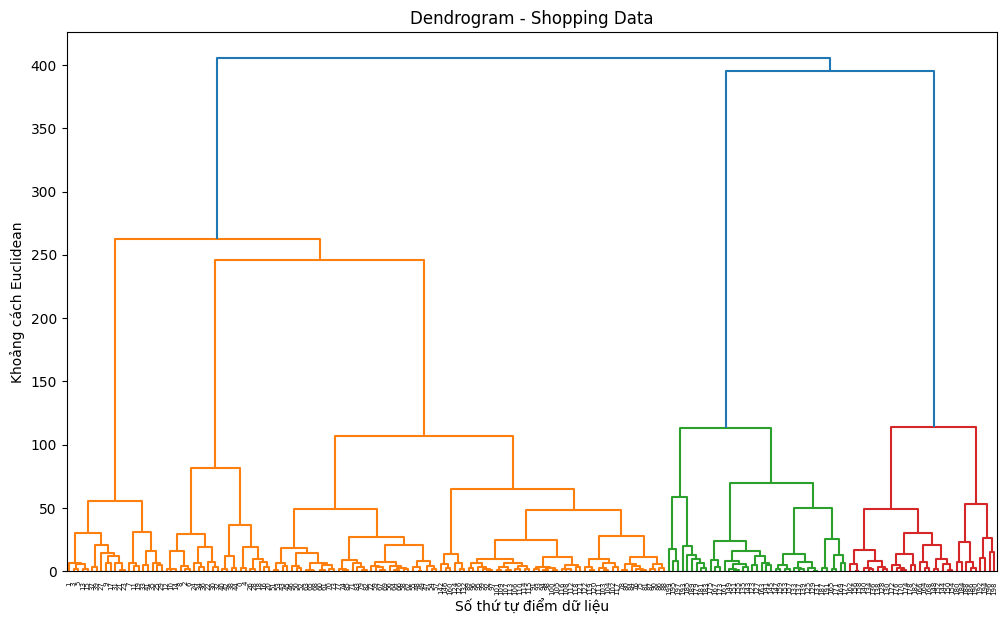

In [23]:
# 3.3. Trực quan hóa quá trình phân cấp bằng Dendrogram 
plt.figure(figsize=(12, 7))
plt.title("Dendrogram - Shopping Data")
# Sử dụng phương pháp 'ward' để giảm thiểu phương sai trong cụm
dend = shc.dendrogram(shc.linkage(data, method='ward'))
plt.xlabel("Số thứ tự điểm dữ liệu")
plt.ylabel("Khoảng cách Euclidean")
plt.show()

In [ ]:
# 3.4. Xây dựng mô hình AgglomerativeClustering với n_clusters = 5 ---
model = AgglomerativeClustering(n_clusters=2, metric='euclidean', linkage='ward')
labels = model.fit_predict(data)

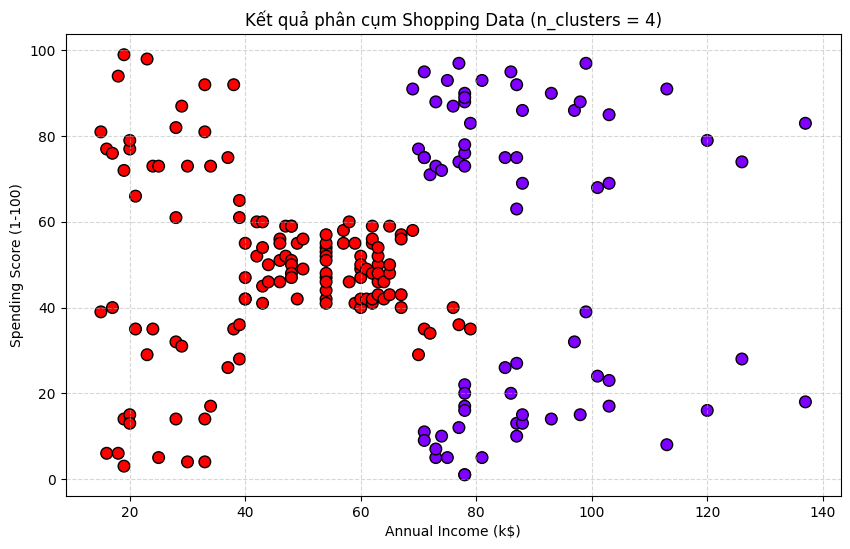

In [27]:
# Trực quan hóa kết quả phân cụm
plt.figure(figsize=(10, 6))
plt.scatter(data[:, 0], data[:, 1], c=labels, cmap='rainbow', edgecolors='k', s=70)
plt.title("Kết quả phân cụm Shopping Data (n_clusters = 4)")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Số cụm k = 2: Silhouette Score = 0.3671
Số cụm k = 3: Silhouette Score = 0.4618
Số cụm k = 4: Silhouette Score = 0.4917
Số cụm k = 5: Silhouette Score = 0.5530


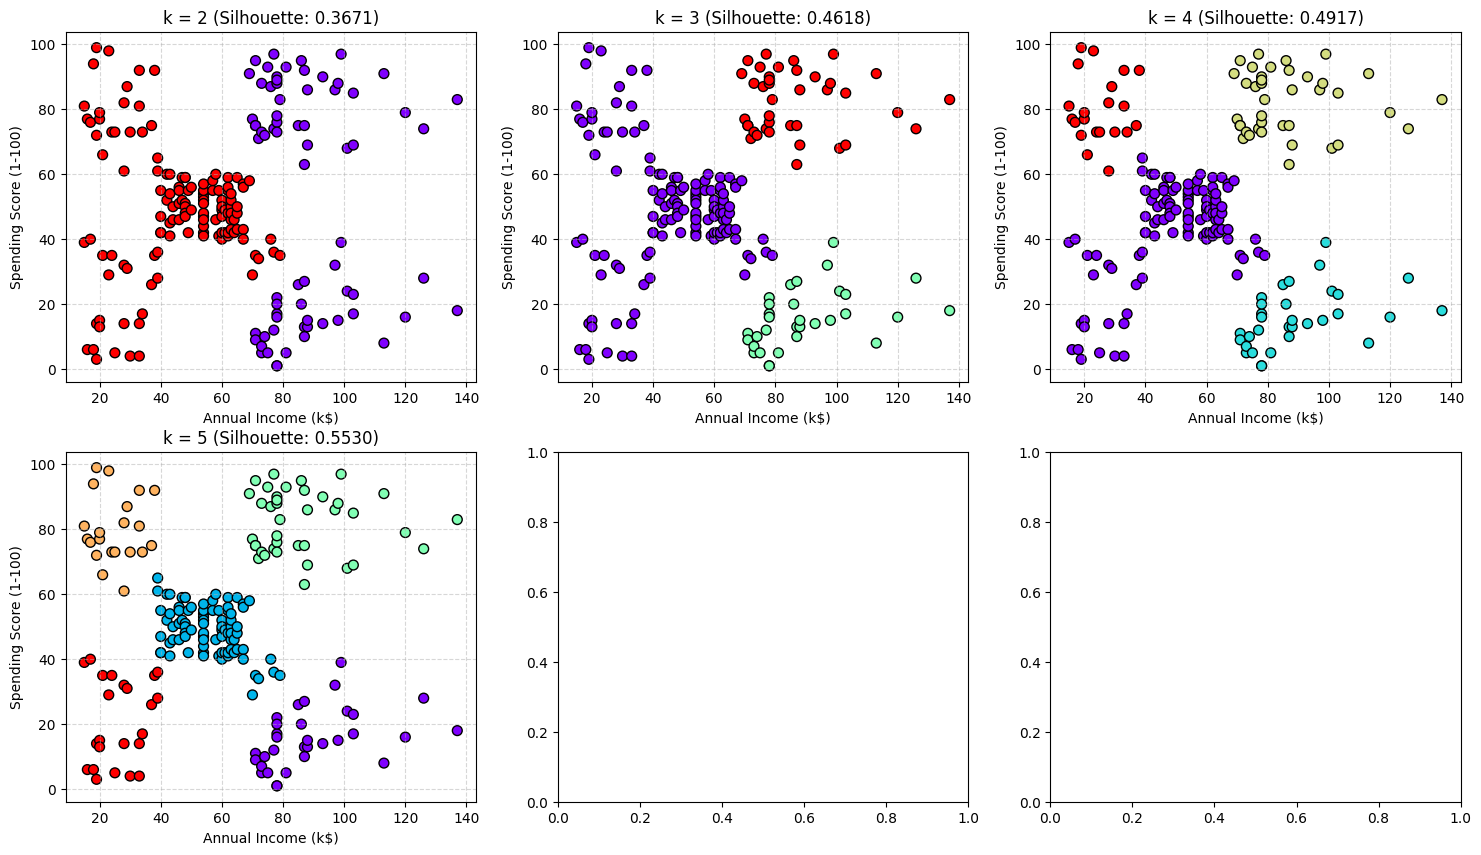

In [29]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for i,k in enumerate(range(2,6)):
    models = AgglomerativeClustering(n_clusters=k)
    labels = models.fit_predict(data)
    score = silhouette_score(data, labels)
    print(f"Số cụm k = {k}: Silhouette Score = {score:.4f}")
    # Trực quan hóa lên subplot tương ứng
    scatter = axes[i].scatter(data[:, 0], data[:, 1], c=labels, cmap='rainbow', edgecolors='k', s=50)
    axes[i].set_title(f"k = {k} (Silhouette: {score:.4f})")
    axes[i].set_xlabel("Annual Income (k$)")
    axes[i].set_ylabel("Spending Score (1-100)")
    axes[i].grid(True, linestyle='--', alpha=0.5)